## Earthquake Prediction and Risk Analysis System

This project aims to analyze earthquake data using machine learning techniques and generate predictive insights based on historical seismic activity.

The workflow includes:

Real-time data collection from the USGS API
Data preprocessing and feature engineering
Spatial clustering of earthquake regions
Predictive modeling using Random Forest
Performance evaluation using regression metrics
Visualization of predictions and risk distribution

The goal is to build an intelligent system that can:

Identify patterns in earthquake occurrences
Estimate potential future magnitudes

In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import requests

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.cluster import KMeans

import folium

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import warnings
warnings.filterwarnings("ignore")

In [2]:
import requests
import pandas as pd

url = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query"
    "?format=geojson"
    "&starttime=2000-01-01"
    "&endtime=2026-04-04"
    "&minmagnitude=3.0"
    "&minlatitude=35"
    "&maxlatitude=43"
    "&minlongitude=25"
    "&maxlongitude=45"
)

response = requests.get(url)
data = response.json()

print("Feature sayısı:", len(data["features"]))

# JSON → tabloya çevir
rows = []

for f in data["features"]:
    props = f["properties"]
    coords = f["geometry"]["coordinates"]

    rows.append({
        "time": props["time"],
        "magnitude": props["mag"],
        "place": props["place"],
        "longitude": coords[0],
        "latitude": coords[1],
        "depth": coords[2]
    })

df = pd.DataFrame(rows)

print(df.head())

# ✅ artık çalışır
df.to_parquet("deprem.parquet", index=False)

print("✔ parquet kaydedildi")

Feature sayısı: 9989
            time  magnitude                          place  longitude  \
0  1775158515875        4.3    35 km SSE of Finike, Turkey    30.2836   
1  1775154171853        4.2  14 km ESE of Sındırgı, Turkey    28.3150   
2  1773842449257        4.1       27 km SSE of Fry, Greece    27.0562   
3  1773641028446        4.4    12 km ENE of Buldan, Turkey    28.9692   
4  1773362115424        5.3    15 km WNW of Niksar, Turkey    36.7861   

   latitude  depth  
0   35.9955   10.0  
1   39.1721   10.0  
2   35.1975   10.0  
3   38.0807   10.0  
4   40.6607   10.0  
✔ parquet kaydedildi


In [3]:
# ==============================
# 4. FEATURE ENGINEERING
# ==============================

# Lag features
df["lag1"] = df["magnitude"].shift(1)
df["lag2"] = df["magnitude"].shift(2)

# Rolling mean
df["rolling_mean"] = df["magnitude"].rolling(3).mean()

df = df.dropna()

# ==============================
# 5. CLUSTERING
# ==============================
df = df.dropna()

kmeans = KMeans(n_clusters=5, random_state=42)
df["cluster"] = kmeans.fit_predict(df[["latitude", "longitude"]])

print("Clustering added. Feature engineering completed.")

Clustering added. Feature engineering completed.


In [4]:
# ==============================
# 6. MODEL TRAINING (RandomForest)
# ==============================

features = ["latitude", "longitude", "lag1", "lag2", "rolling_mean", "cluster"]
target = "magnitude"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model training completed.")

Model training completed.


In [5]:
# ==============================
# 7. PERFORMANCE EVALUATION
# ==============================

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("===== PERFORMANCE =====")
print(f"RMSE: {rmse}")
print(f"MAE : {mae}")
print(f"R2  : {r2}")

===== PERFORMANCE =====
RMSE: 0.09727234851068846
MAE : 0.05129404404404394
R2  : 0.9601272355724639


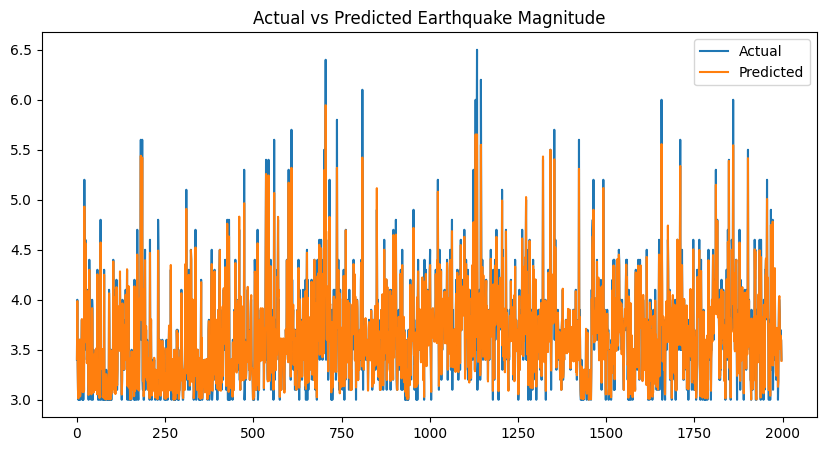

In [6]:
# ==============================
# 8. VISUALIZATION
# ==============================

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Earthquake Magnitude")
plt.show()

In [9]:
# 2000 Yılı sonrası 5 ve üzeri depremler
df_filtered = df[df["magnitude"] >= 5.5]

m = folium.Map(
    location=[df_filtered["latitude"].mean(), df_filtered["longitude"].mean()],
    zoom_start=5
)

def get_color(mag):
    if mag < 6:
        return "blue"
    elif mag < 6.5:
        return "orange"
    else:
        return "red"

for i in range(len(df_filtered)):
    lat = df_filtered.iloc[i]["latitude"]
    lon = df_filtered.iloc[i]["longitude"]
    mag = df_filtered.iloc[i]["magnitude"]
    depth = df_filtered.iloc[i]["depth"]

    folium.CircleMarker(
        location=[lat, lon],
        radius=mag/3,
        color=get_color(mag),
        fill=True,
        fill_opacity=0.7,
        popup=f"""
        <b>Magnitude:</b> {mag} <br>
        <b>Depth:</b> {depth} km
        """
    ).add_to(m)

m

In [10]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [11]:
# Zaman sıralaması
df = df.sort_values("time")

# Sadece magnitude al (LSTM için sade model)
data = df[["magnitude"]].values

# Normalize et
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [12]:
def create_sequences(data, seq_length=10):
    X, y = [], []
    
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
        
    return np.array(X), np.array(y)

sequence_length = 10

X, y = create_sequences(data_scaled, sequence_length)

In [13]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [14]:
model = Sequential()

model.add(LSTM(50, return_sequences=False, input_shape=(sequence_length, 1)))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

In [15]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0088 - val_loss: 0.0076
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0085 - val_loss: 0.0070
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0085 - val_loss: 0.0076
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0084 - val_loss: 0.0083
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0085 - val_loss: 0.0090
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0085 - val_loss: 0.0073
Epoch 7/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0084 - val_loss: 0.0076
Epoch 8/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0084 - val_loss: 0.0072
Epoch 9/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0084 - val_loss: 0.0072
Epoch 10/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0083 - val_loss: 0.0074


In [16]:
predictions = model.predict(X_test)

# Scale geri al
predictions = scaler.inverse_transform(predictions)
y_test_real = scaler.inverse_transform(y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test_real, predictions))
mae = mean_absolute_error(y_test_real, predictions)
r2 = r2_score(y_test_real, predictions)

print("===== LSTM PERFORMANCE =====")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

===== LSTM PERFORMANCE =====
RMSE: 0.4126
MAE : 0.2740
R2  : -0.1281


# LSTM PIPELINE
This implementation builds a Long Short-Term Memory (LSTM) model to learn
temporal patterns in earthquake magnitude data. The objective is to evaluate
whether past magnitudes contain predictive signals for future values.

In [18]:
# 1. LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [19]:
# 2. DATA PREPARATION

df = df.copy()
# Ensure time column is datetime and sorted
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")
# Select magnitude only
data = df[["magnitude"]].values
# Normalize data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [21]:
# 3. PARAMETERS

seq_len=12

def create_sequences(data, seq_len):
    X, y = [], []   
    
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
        
    return np.array(X), np.array(y)   

X, y = create_sequences(data_scaled, seq_len)

In [22]:
# 5. TRAIN / TEST SPLIT (NO SHUFFLE)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [26]:
# 6. LSTM MODEL

model = Sequential([
LSTM(64, input_shape=(seq_len, 1)),
Dense(32, activation='relu'),
Dense(1)
])

model.compile(
optimizer='adam',
loss='mean_squared_error'
)

In [27]:
# 7. TRAINING

history = model.fit(
X_train, y_train,
epochs=15,
batch_size=16,
validation_data=(X_test, y_test),
verbose=1
)

Epoch 1/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0086 - val_loss: 0.0069
Epoch 2/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0084 - val_loss: 0.0071
Epoch 3/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0084 - val_loss: 0.0070
Epoch 4/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0083 - val_loss: 0.0069
Epoch 5/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0083 - val_loss: 0.0073
Epoch 6/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0083 - val_loss: 0.0068
Epoch 7/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0083 - val_loss: 0.0067
Epoch 8/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0083 - val_loss: 0.0068
Epoch 9/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0082 - val_loss: 0.0067
Epoch 10/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0082 - val_loss: 0.0067
Epoch 11/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0082 - val_loss: 0.0071
Epoch 12/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step

In [28]:
# 8. PREDICTION
predictions = model.predict(X_test)

# Inverse transform

predictions = scaler.inverse_transform(predictions)
y_test_real = scaler.inverse_transform(y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [29]:
# 9. EVALUATION

rmse = np.sqrt(mean_squared_error(y_test_real, predictions))
mae = mean_absolute_error(y_test_real, predictions)
r2 = r2_score(y_test_real, predictions)

print("\n===== LSTM PERFORMANCE =====")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")


===== LSTM PERFORMANCE =====
RMSE: 0.3872
MAE : 0.2642
R2  : 0.0062


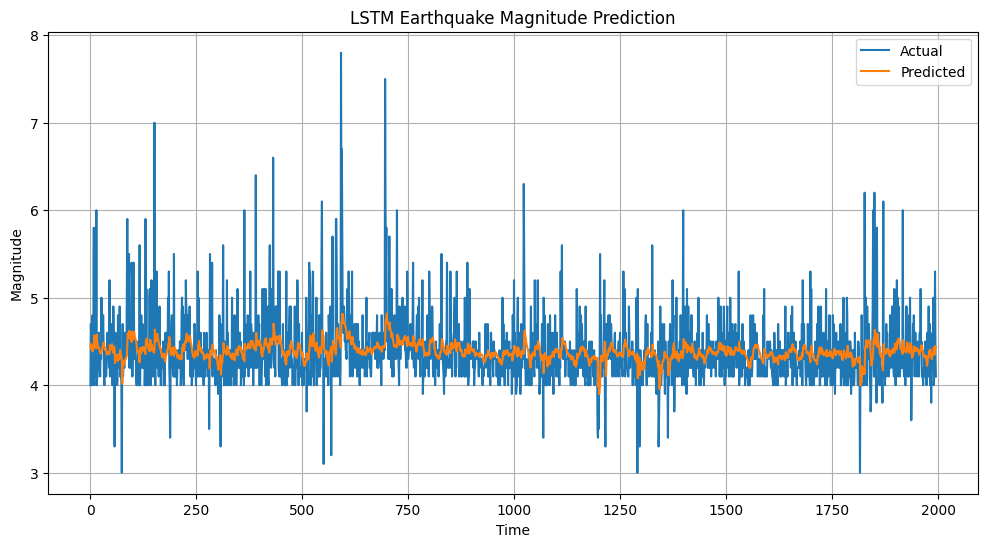

In [30]:
# 10. VISUALIZATION

plt.figure(figsize=(12,6))
plt.plot(y_test_real, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("LSTM Earthquake Magnitude Prediction")
plt.xlabel("Time")
plt.ylabel("Magnitude")
plt.grid()
plt.show()

In [33]:
import joblib

model.save("earthquake_model.keras")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## CONCLUSION

The LSTM model captures limited temporal dependencies in earthquake magnitude
data. However, due to the stochastic nature of seismic activity, predictive
performance is inherently constrained.

This pipeline provides a robust baseline for further improvements such as:

* Multi-feature input (latitude, longitude, depth)
* Classification tasks (event occurrence prediction)
* Hybrid deep learning models